# Исследование данных и обучение моделей.

Описание проекта: чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Ваша задача — построить модель, которая будет её предсказывать.

Основные итоги обзора и предобработки данных:
* В данных большое количество пропусков в 3 файлах: пропуски в материалах означают неиспользование материала в данной партии, кол-во пропусков достигало 99% поэтому редкие материалы мы объединили в один столбец для каждого типа other_bulk и other_wire. Причина пропусков в температуре неизвестна, всего отсутсвует информация о 739 партий (23% данных), в каждой партии был лишь первый замер температуры, остальные (втч последний) осутствуют, скорее всего ошибка в записи данных;
* Были обработаны аномально низкие значения температуры (4 партии удалены, тк температура ниже плавления металла) и реактивной мощности (1 строка заменена на медианное значение);
* Во всех файлах разное количество ключей партий, суммарно отсутсвует 148 партий, больше всего пропущено в материалах, скорее всего причина пропуска та же - неиспользование материалов вовсе, отчего нет и записи о партии;
* На пропущенные партии в материалах приходятся самые высокие температуры во всех данных, в основном это пропуски в записи о проволочных материалах, либо совместные пропуски в bulk и wire. Данные в которых пропуски в материалах остуствуют не достигают таких температур.

## Исследовательский анализ итоговой таблицы

In [1]:
import os
import sys
import shap
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from catboost import CatBoostRegressor
from typing import Callable, Dict, Any, Optional
os.environ['MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT'] = 'True'
import mlflow

sys.path.append(os.path.abspath(os.path.join('..')))
from scr.utils import (plot_distribution, plot_pairplot, 
                        plot_scatterplot, plot_correlation_matrix)

RANDOM_STATE=110826
TEST_SIZE=0.25

Исследуем итоговую таблицу чтобы понять распределение, понять какие признаки наиболее важные, а какие нет, также создадим новые признаки и посмотрим корреляцию между признаками.

In [2]:
df = pd.read_csv('../data/df_temp_prep.csv', index_col='key')
df.head()

,temp,start_temp,max_temp,duration,activ,react,heating_time,total_power,gas,bulk_12,bulk_14,bulk_15,other_bulk,wire_1,other_wire,bulk_time_diff,wire_time_diff
key,,,,,,,,,,,,,,,,,
1,1613.0,1571.0,1618.0,1714.0,3.036730,2.142821,1098.0,3.716640,29.749986,206.0,150.0,154.0,43.0,60.059998,0.00000,1085.0,0.0
2,1602.0,1581.0,1604.0,1265.0,2.139408,1.453357,811.0,2.586371,12.555561,206.0,149.0,154.0,73.0,96.052315,0.00000,1000.0,0.0
3,1599.0,1596.0,1600.0,1753.0,4.063641,2.937457,655.0,5.014163,28.554793,205.0,152.0,153.0,34.0,91.160157,0.00000,983.0,0.0
4,1625.0,1601.0,1625.0,1220.0,2.706489,2.056992,741.0,3.399456,18.841219,207.0,153.0,154.0,81.0,89.063515,0.00000,878.0,0.0
5,1602.0,1576.0,1602.0,1536.0,2.252950,1.687991,869.0,2.815155,5.413692,203.0,151.0,152.0,78.0,89.238236,9.11456,205.0,310.0


**Температуры**

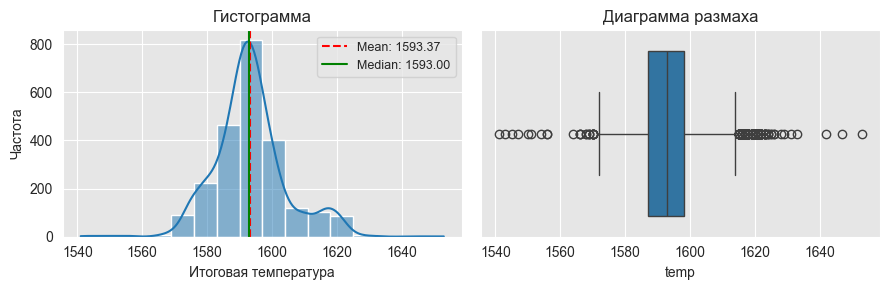

In [3]:
plot_distribution(df, 'temp', 'Итоговая температура')

Целевой признак распределен нормально с небольшой асимметрией справа: партии с высокой температурой, межквартильный размах имеет узкий диапазон значений с 1587 до 1598 градусов, прогноз модели нужно будет делать в небольшом отрезке. Имеются выбросы вплоть до 1653 градусов, нужно проверить есть ли у этих партий что-то общее.

In [4]:
df.describe().round(2)

,temp,start_temp,max_temp,duration,activ,react,heating_time,total_power,gas,bulk_12,bulk_14,bulk_15,other_bulk,wire_1,other_wire,bulk_time_diff,wire_time_diff
count,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00,2325.00
mean,1593.37,1587.37,1601.34,2323.42,3.13,2.30,808.04,3.88,11.38,208.51,153.97,120.03,127.46,102.41,22.77,986.35,209.90
std,11.21,23.62,15.28,1385.57,1.22,0.90,340.83,1.52,6.40,157.14,81.40,84.67,112.31,43.54,49.14,816.03,390.38
min,1541.00,1519.00,1558.00,339.00,0.27,0.20,57.00,0.33,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1587.00,1571.00,1591.00,1581.00,2.30,1.67,581.00,2.84,7.28,105.00,105.00,0.00,62.00,73.21,0.00,501.00,0.00
50%,1593.00,1587.00,1598.00,2046.00,3.04,2.23,778.00,3.77,10.10,206.00,149.00,107.00,107.00,101.09,0.00,894.00,0.00
75%,1598.00,1603.00,1611.00,2793.00,3.83,2.83,993.00,4.77,14.22,283.00,204.00,204.00,165.00,128.07,27.17,1340.00,397.00
max,1653.00,1660.00,1662.00,23674.00,12.38,8.95,4189.00,15.27,78.00,1849.00,636.00,405.00,1276.00,330.31,407.15,13683.00,5937.00


Большинство признаков имеют выбросы, максимальные значения у некоторых больше среднего в 10 раз, такие партии могут быть сложными для моделей, если они напрямую не влияют на температуру.

Для исследования и лучшего понимания причины повышенных температур: пометим партии с температурой выше среднего отдельным признаком, чтобы иметь возможность рассмотреть распределения в двух группах.

In [5]:
df['is_hot'] = np.where(df['temp'] > 1593, 1, 0)

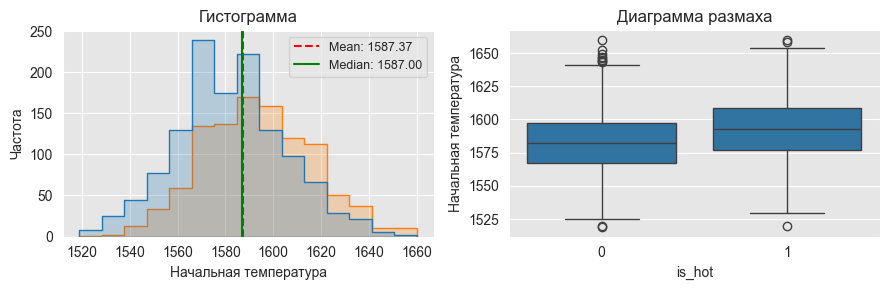

In [6]:
plot_distribution(data=df, column='start_temp', 
                  title='Начальная температура', hue='is_hot')

Видно, что более горячие партии изначально имеют высокую температуру тк все данные смещены вправо, те в среднем они имеют более высокую температуру.

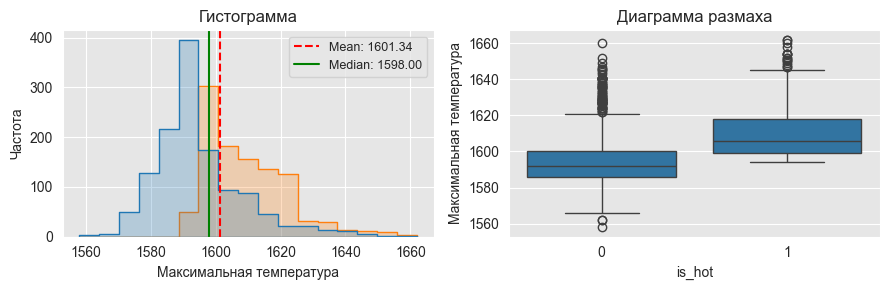

In [7]:
plot_distribution(df, 'max_temp',  'Максимальная температура', 'is_hot')

По графику максимальной температуры за все замеры ещё лучше видно разделение, мы не может использовать этот признак для обучения тк часто он совпадает с конченой температурой, но по нему в том числе можно изучить что влияет на повышенную температуру.

**Нагрев электродами**

In [8]:
arc_cols = ['activ', 'react', 'total_power', 'heating_time']

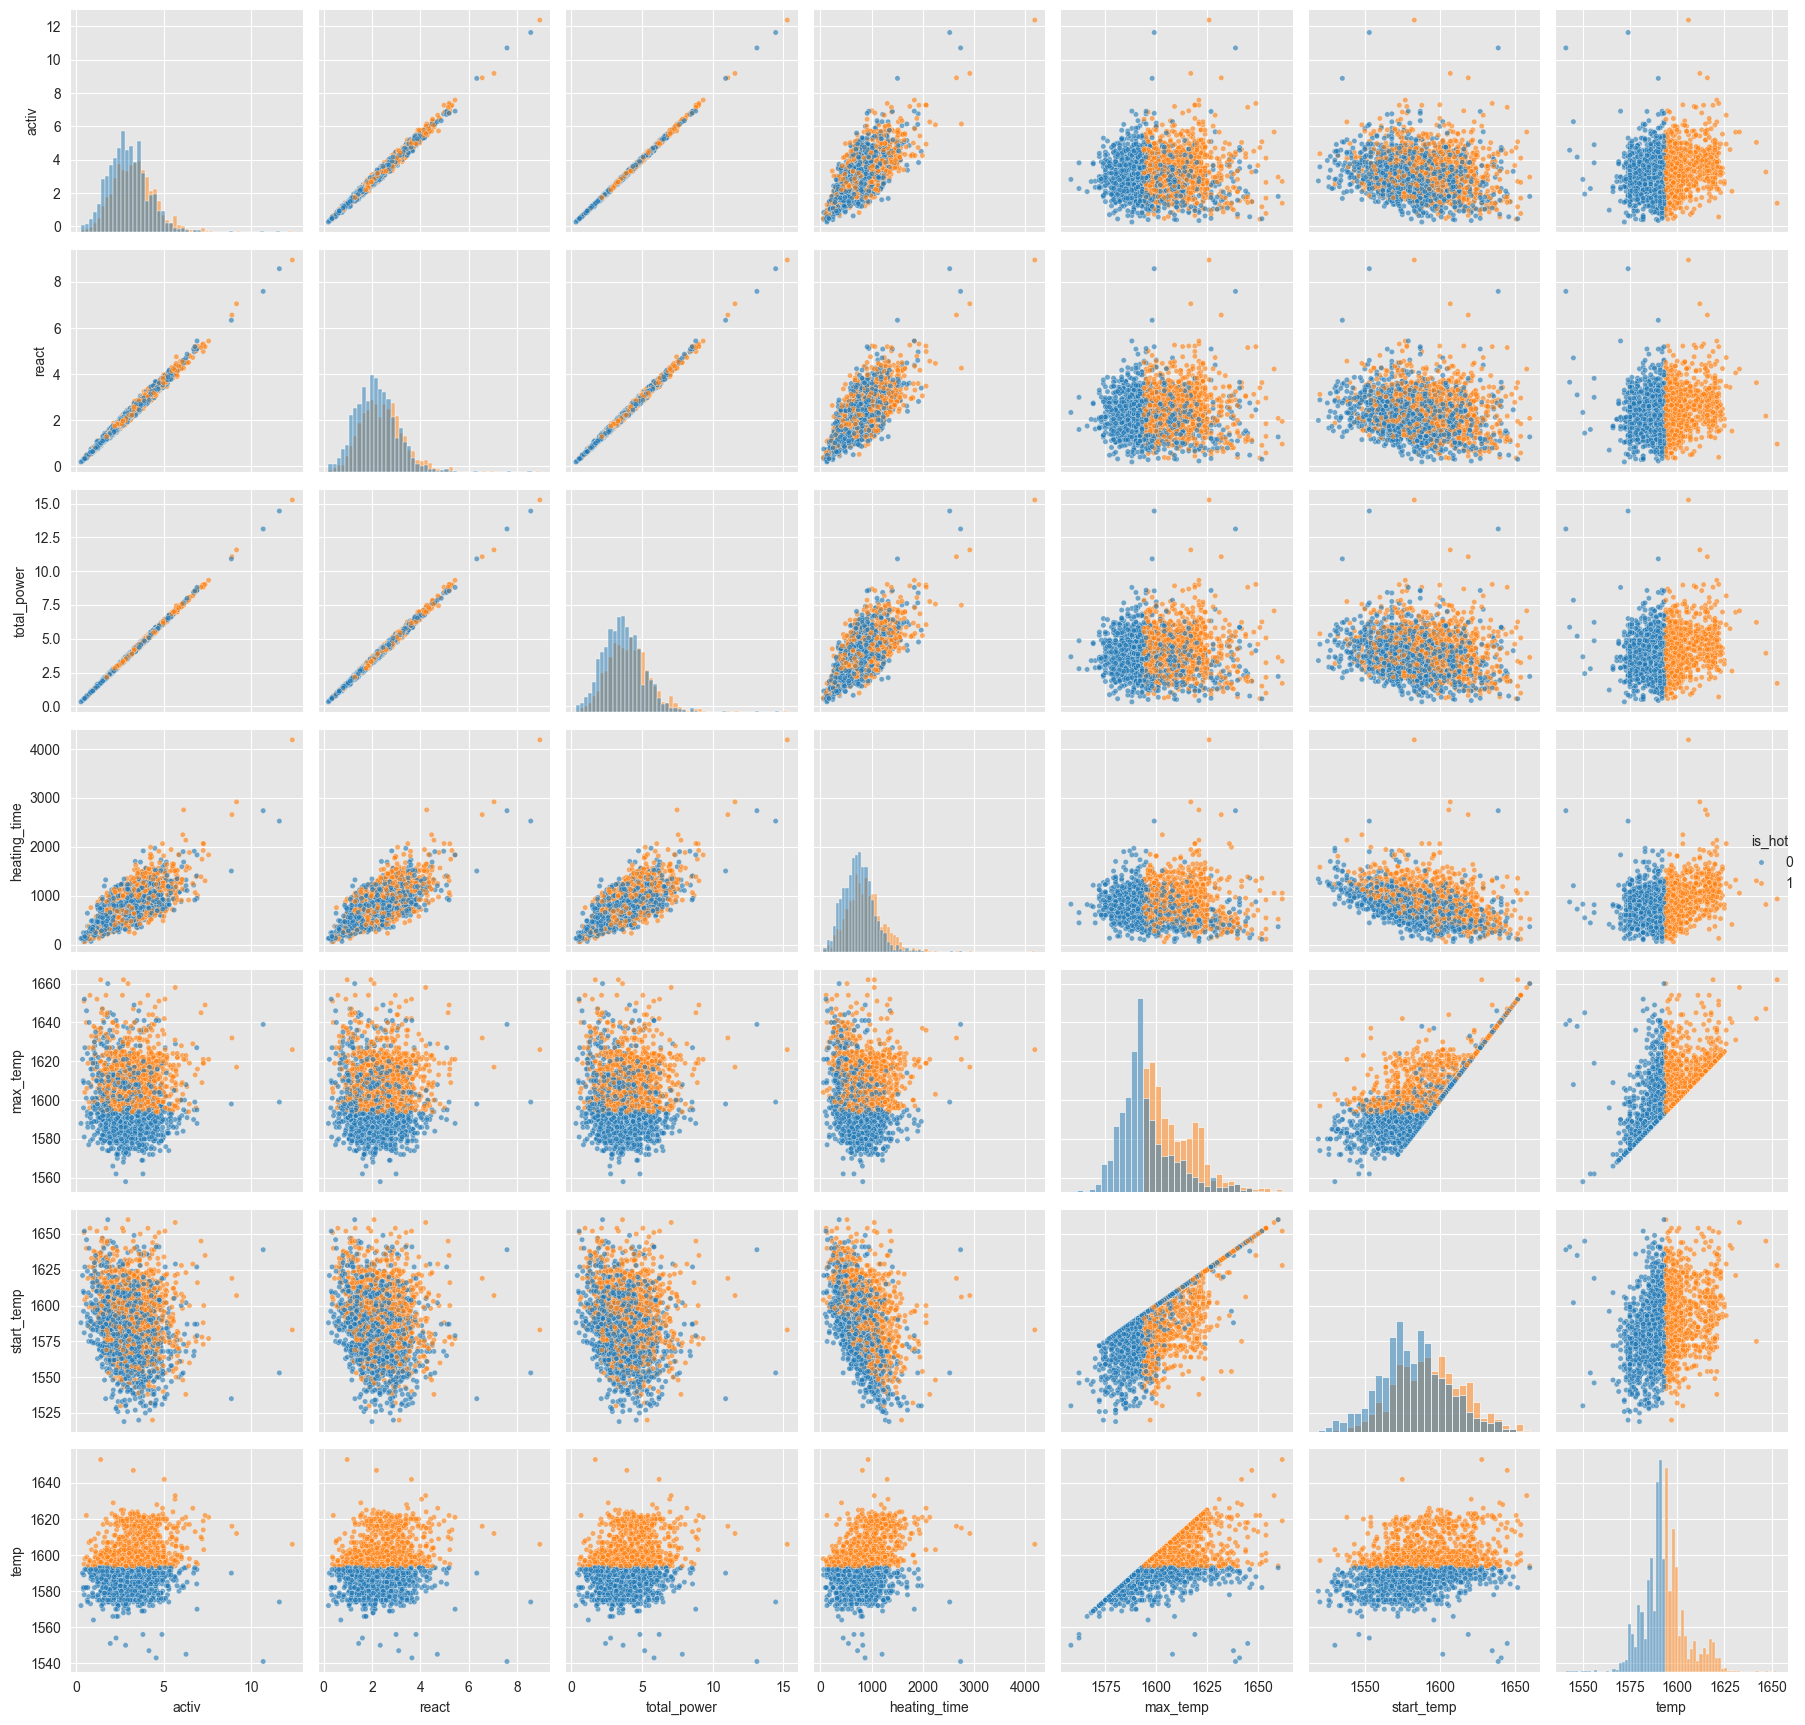

In [9]:
plot_pairplot(
    df[arc_cols + ['is_hot', 'max_temp', 'start_temp', 'temp']], hue='is_hot', corner=False
)

Признаки мощностей имеют полную линейную связь друг с другом, необхдимо будет убрать часть из них. Сами по себе призаки слабо связаны с температурой, наибольшая связь у времени нагрева, видно что более высокие температуры нагрваются дольше (распределение правее по графику temp/heating_time). График start_temp/heating_time наоборот показывает снижении температуры с увеличением продолжительности нагрева;

Температурные признаки естественно связанны с конечной температурой, чем выше стартовая или максимальная температура на итерациях, тем горячее будет ковш с металлом в конце цикла. Стартовая и максимальная температура также сильно коррелируют, наименьшие значения стартовой температуры дают более низкие значения максимальной температуры на всех итерациях;

In [10]:
bulk_cols = ['bulk_12', 'bulk_14', 'bulk_15', 'other_bulk', 'bulk_time_diff']
targets = ['max_temp', 'start_temp', 'temp']

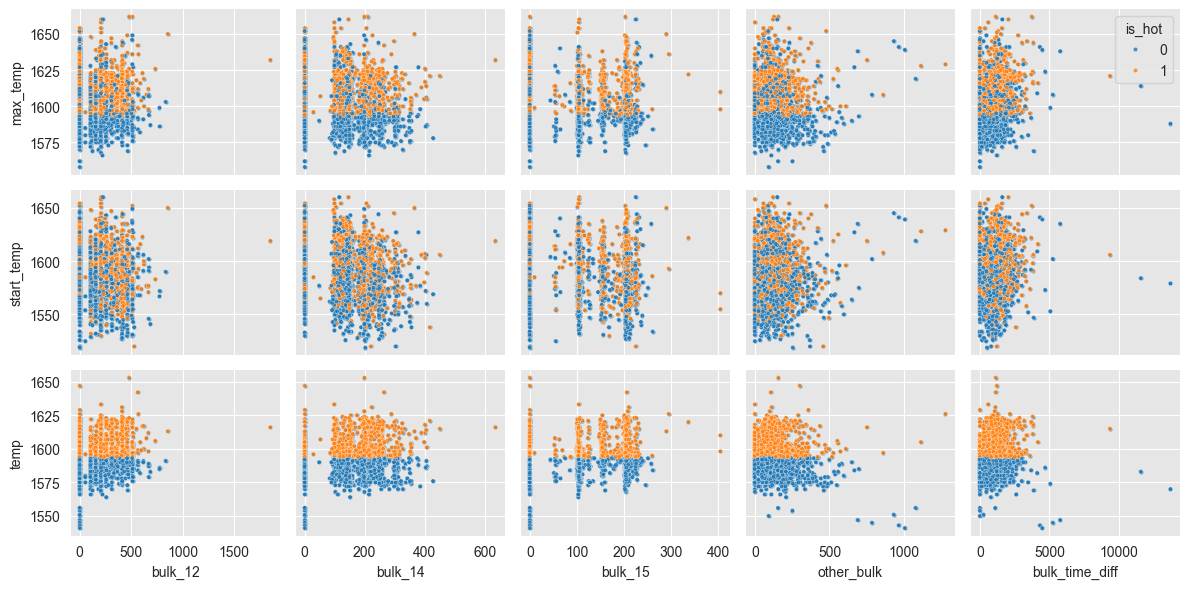

In [11]:
plot_scatterplot(
    df,
    features=bulk_cols,
    targets=targets,
    hue='is_hot', s=10
)

Какой-то явной связи между сыпучими материалами и температурой не наблюдается, bulk_14 и bulk_15 выглядят бесполезными.

In [12]:
other_cols = ['wire_1', 'other_wire', 'wire_time_diff', 'gas' , 'duration']

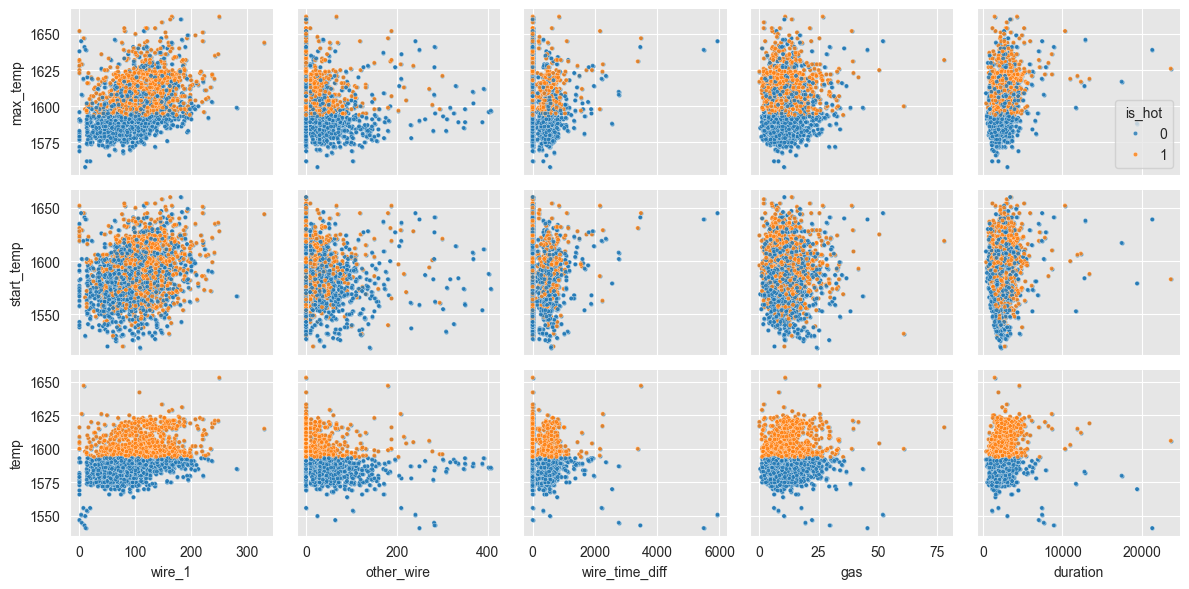

In [13]:
plot_scatterplot(
    df,
    features=other_cols,
    targets=targets,
    hue='is_hot', s=10
)

Связь с температурами есть, с увеличением `wire_1` значения объёма растёт и дисперсия температуры, other_wire наоборот показывает снижение диспрерсии температуры с увеличением значения, на нулевые данные приходятся высокие температуры. `gas` и `duration` почти никак не связаны с температурами.

Чего-то необычного в горячих партиях обнаружить не удалось, посмотрим на корреляцию признаков с целевым. Так как в большинстве признаков распределение не нормальное и имеются выбросы, будем использовать ранговую корреляцию.

In [14]:
df = df.drop(columns=['is_hot'])

Признаки показывают слабую или умеренную корреляцию с конечной температурой, самое высокое значение у начальной температуры и wire_1, bulk_12, bulk_15. У other_wire самая сильная обратная корреляция. С максимальной температурой за все итерации у некоторых призанков связь сильнее, продолжительность нагрева и wire_1 показывают наиболее сильную корреляцию, в основном значения на том же уровне либо ниже чем у связи с конечной температурой.

Часть признаков как и ожидалось показывают мультиколлинеарность, по этому оставим самые важные среди них, удалим время подачи проволочный материалов (высокая корреляция с other_bulk) и активную и реактивную мощность, мы видели что их распределения идентичны, а полная мощность связанна с целевым сильнее.

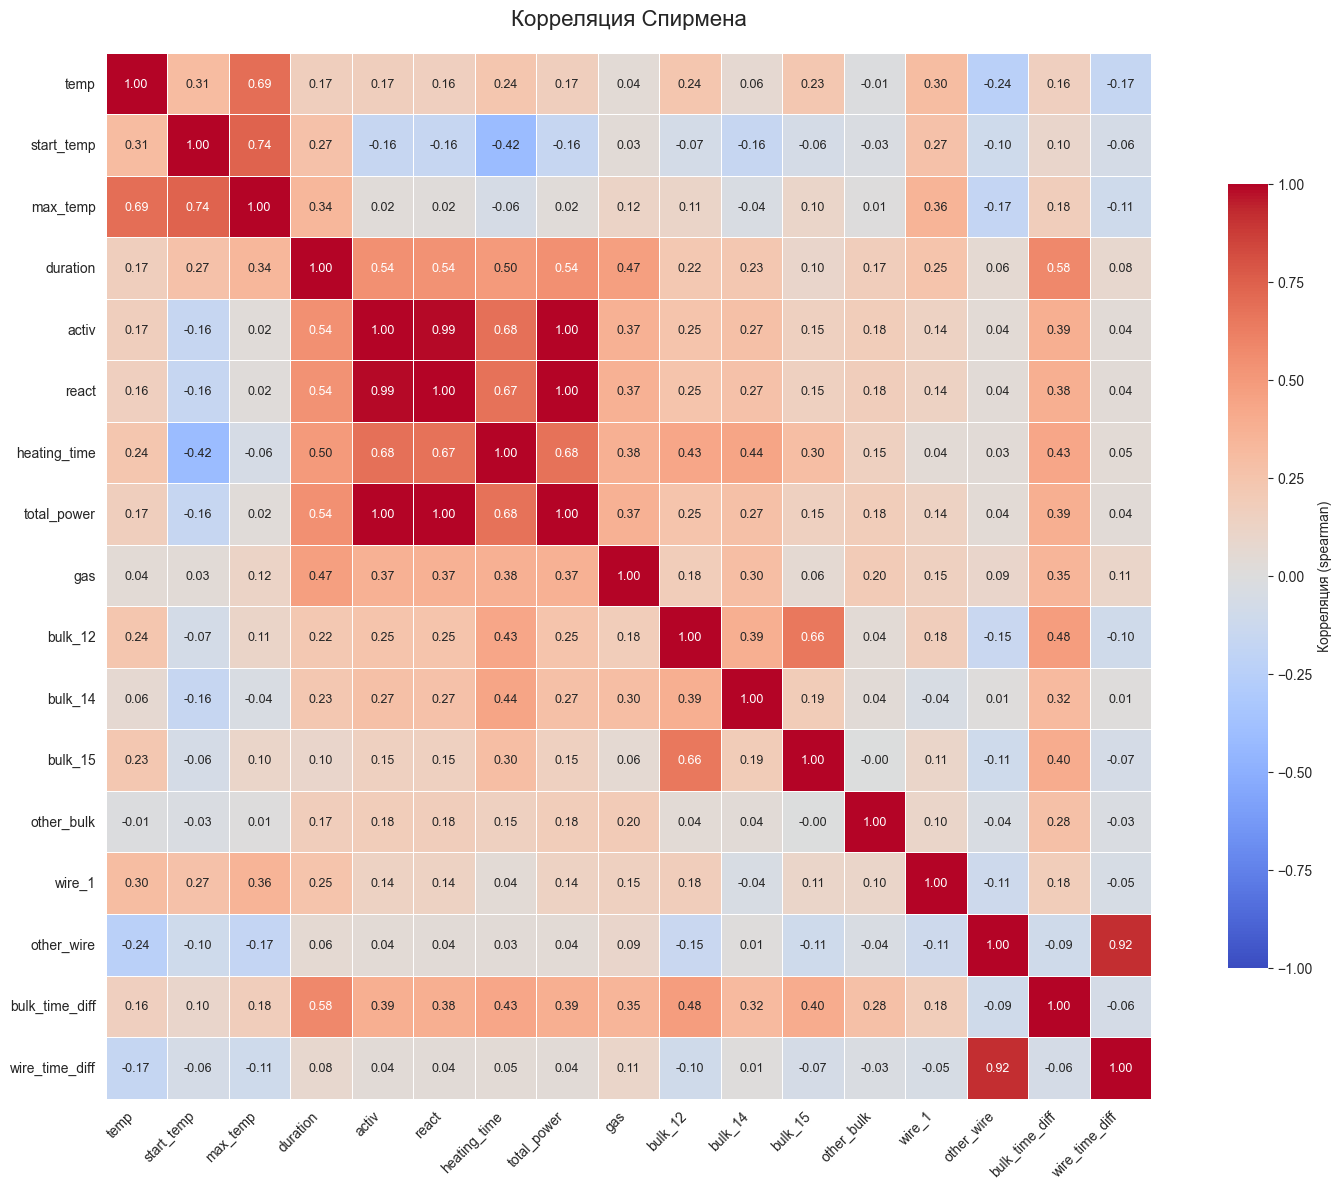

In [15]:
plot_correlation_matrix(
    df,
    method='spearman',
    figsize=(16, 12),
    title='Корреляция Спирмена'
)

Попробуем найти полиномиальные признаки, возможно они будут полезны.

In [16]:
df = df.drop(columns=['activ', 'react', 'wire_time_diff', 'max_temp'])

In [17]:
X = df.drop(columns=['temp'])

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(X.columns)

df_poly = pd.DataFrame(X_poly, columns=feature_names, index=df.index)
df_poly['target'] = df['temp']

corr = df_poly.corr(method='spearman')['target'].sort_values(ascending=False)
corr.head(5)

target                 1.000000
heating_time wire_1    0.359637
bulk_15 wire_1         0.334745
bulk_12 wire_1         0.317121
total_power wire_1     0.310351
Name: target, dtype: float64

Наиболее сильные связи показывают признаки помноженные на wire_1. Корреляция выше чем у оригинальных признаков.

**Промежуточный вывод**

Мы проанализировали итоговую таблицу и провели корреляционный анализ. Целевой признак конечной температуры распределен нормально, большинство значений находится в диапазоне от 1580 до 1600 градусов, стандартное отклонение 11 градусов. Минимальная температура 1541, максимальная 1653.

Признаки из одного источника имеют мультиколлинеарность, так все признаки из данных о нагреве имеют высокую линейную связь друг с другом, мы удалили наименее важные из них. 

Явной связи между высокой температурой и признаками не выявленно, признаки показывают слабую или умеренную корреляцию c целевым, самая высокая связь с начальной температурой, wire_1, bulk_12 и bulk_15. С максимальной температурой за все итерации наиболее сильную корреляцию показали duration (длительность между первым и последним замером) и wire_1, связь с максимальной температурой даже сильнее чем с конечной, есть основания предположить, что увеличение этих признаков повышает конечную температуру. Также мы удалили самые неинформативные признаки, корреляция которых была околонулевая.

Мы рассмотрели полиномиальные признаки, среди них есть те которые показывают более сильную связь чем признаки из оригинальных данных. Самые резульатативные связи получаются с wire_1.

## Подготовка

Чтобы проверить и сравнить разные комбинации признаков и гиперпараметров будем сохранять историю в mlflow, для оптимизации гиперпараметров будем использовать optuna, обучение проводится на кросс-валидации, оптимизируемая метрика MAE, в качестве дополнительной метрики возьмём R2.

Для дочерних запусков будут сохраняться параметры и средние метрики. Для всего запуска (и лучшей модели) будут логироваться параметры, препроцессинг (если использовался), количество и список признаков.

In [18]:
def optimize_model(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    model_factory: Callable[[Dict[str, Any]], Any],
    suggest_params: Callable[[optuna.Trial], Dict[str, Any]],
    n_trials: int = 20,
    use_scaling: bool = False,
    run_name: str = 'Optuna_Search',
    cv: int = 5,
    n_jobs: int = -1,
    random_state: int = RANDOM_STATE,
) -> optuna.Study:
    '''
    Оптимизация гиперпараметров регрессионной модели
    с помощью Optuna + MLflow + cross-validation.

    Оптимизируемая метрика: MAE.
    '''
    def objective(trial: optuna.Trial) -> float:
        with mlflow.start_run(run_name=f'trial_{trial.number}', nested=True):

            # Гиперпараметры текущего trial
            params = suggest_params(trial)
            mlflow.log_params(params)

            model = model_factory(params)

            # Масштабирование при необходимости
            if use_scaling:
                model = Pipeline([
                    ('scaler', StandardScaler()),
                    ('model', model)
                ])

            cv_results = cross_validate(
                model,
                X_train,
                y_train,
                cv=cv,
                scoring={
                    'mae': 'neg_mean_absolute_error',
                    'r2': 'r2'
                },
                n_jobs=n_jobs,
                error_score='raise'
            )

            mae = -cv_results['test_mae'].mean()
            r2 = cv_results['test_r2'].mean()

            mlflow.log_metric('cv_MAE', mae)
            mlflow.log_metric('cv_R2', r2)

            trial.set_user_attr('cv_R2', r2)
            
            return mae

    # родительский запуск
    with mlflow.start_run(run_name=run_name):

        # запись признаков
        if hasattr(X_train, 'columns'):
            feature_names = list(X_train.columns)
            mlflow.log_param(
                'features_list',
                ', '.join(feature_names))
            
            mlflow.log_param(
                'features_len',
                len(feature_names))

        mlflow.log_param(
            'preprocessing',
            'StandardScaler' if use_scaling else 'none')

        # Optuna study
        study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(
                seed=random_state))

        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=True)
        
        mae = study.best_trial.value
        r2 = study.best_trial.user_attrs['cv_R2']

        mlflow.log_params(study.best_params)
        mlflow.log_metric('best_cv_MAE', mae)
        mlflow.log_metric('best_cv_R2', r2)

        print(f'Лучшие параметры: {study.best_params}')
        print(f'Лучший MAE: {mae:.5f}')
        print(f'R2: {r2:.5f}')

        return study

In [19]:
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('metal_temp');

In [20]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [21]:
experiment = mlflow.get_experiment_by_name('metal_temp')

cols = [
    'tags.mlflow.runName',
    'params.features_len',
    'params.features_list',
    'metrics.best_cv_MAE',
    'metrics.best_cv_R2'
]

pd.set_option('display.max_colwidth', None)

## Обучение моделей

Были протестированны разные комбинации признаков, лучший набор получился без признаков gas, total_power и bulk_15.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['temp', 'gas', 'total_power', 'bulk_15']), df['temp'], test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_train.shape

(1743, 9)

**Простой прогноз**

In [23]:
mean_pred = np.mean(y_train)
y_pred_mean = np.full_like(y_train, mean_pred)

mean_mae = mean_absolute_error(y_train, y_pred_mean)
    
print(f'MAE при прогнозе средним: {mean_mae:.2f}')

MAE при прогнозе средним: 8.18


Так как диапазон значений конечной температуры не очень большой, средняя ошибка при наивном прогнозе получилась 8 градусов. Будем отталкиваться от этого значения.

Протестируем 3 модели: линейную регрессию, модель опорный векторов и градиентный бустинг.

**Линейная регрессия**

In [24]:
def lr(trial):
    return {
        'alpha': trial.suggest_float('alpha', 0.001, 10, log=True)
    }

In [25]:
study_lr = optimize_model(
    X_train, y_train,
    model_factory=lambda params: Lasso(**params),
    suggest_params=lr,
    n_trials=10,
    use_scaling=True, #standartscaler
    run_name='Lasso_w/o_bulk_15'
)

  0%|          | 0/10 [00:00<?, ?it/s]

Лучшие параметры: {'alpha': 0.020995860917773574}
Лучший MAE: 6.24643
R2: 0.44872


Линейная регрессия показала среднюю ошибку 6.2 градуса, на 2 меньше среднего прогноза. Проверим коэффициенты.

In [26]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(**study_lr.best_params))
])
model.fit(X_train, y_train)

coefficients_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': model[1].coef_
})
coefficients_df.sort_values(by='Коэффициент')

,Признак,Коэффициент
1,duration,-5.499510
7,other_wire,-1.518416
5,other_bulk,-1.244107
4,bulk_14,-0.546000
8,bulk_time_diff,-0.304558
3,bulk_12,-0.015637
6,wire_1,1.583817
0,start_temp,7.568798
2,heating_time,9.592998


Наиболее важными признаками стали Время нагрева, стартовая температура и время между начальным и конечным измерением температуры.

In [27]:
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string='tags.mlflow.parentRunId IS NULL AND params.alpha IS NOT NULL',
    order_by=['metrics.best_cv_MAE']
)
runs[cols][:5]

,tags.mlflow.runName,params.features_len,params.features_list,metrics.best_cv_MAE,metrics.best_cv_R2
0,Lasso_poly,13,"start_temp, duration, heating_time, total_power, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff, heating_time*wire_1, bulk_14*bulk_15",6.168973,0.467740
1,Lasso_poly2,13,"start_temp, duration, heating_time, total_power, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff, heating_time*wire_1, bulk_15*wire_1",6.198828,0.462350
2,Lasso_base,11,"start_temp, duration, heating_time, total_power, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff",6.202296,0.460060
3,Lasso_10_features,10,"start_temp, duration, heating_time, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff",6.208838,0.456621
4,Lasso_w/o_diff,9,"start_temp, duration, heating_time, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire",6.213187,0.456522


Модели регрессии лучше всего отвечали на добавление полиномиальных признаков, лучший МАЕ с 13ю признаками = 6.16

**SVR**

Обучим модели опорных векторов с разными ядрами.

In [28]:
def suggest_svr_linear(trial): 
    return {
        'C': trial.suggest_float('C', 0.01, 100.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 1.0),
        'kernel': 'linear' #линейное ядро
    }

In [29]:
study_svrl = optimize_model(
    X_train, y_train,
    model_factory=lambda params: SVR(**params),
    suggest_params=suggest_svr_linear,
    n_trials=50,
    use_scaling=True, #standartscaler
    run_name='SVR_linear_w/o_bulk15'
)

  0%|          | 0/50 [00:00<?, ?it/s]

Лучшие параметры: {'C': 55.62773528309957, 'epsilon': 0.5171139592319127}
Лучший MAE: 6.22841
R2: 0.44430


SVR с линейным ядром со средней абсолютной ошибкой 6.22 немного лучше обычной регрессии.

In [30]:
def suggest_svr(trial):
    return {
        'C': trial.suggest_float('C', 0.1, 10.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 0.5),
        'kernel': 'rbf',
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
    }

In [31]:
study_svr = optimize_model(
    X_train, y_train,
    model_factory=lambda params: SVR(**params),
    suggest_params=suggest_svr,
    n_trials=100,
    use_scaling=True, #standartscaler
    run_name='SVR_rbf_w/o_bulk15'
)

  0%|          | 0/100 [00:00<?, ?it/s]

Лучшие параметры: {'C': 9.988656356522004, 'epsilon': 0.35547719475167594, 'gamma': 'auto'}
Лучший MAE: 6.02816
R2: 0.44912


SVR с ядром rbf существенно снизил ошибку и лучше всего работал с меньшим числом признаков. `МАЕ = 6.02` лучшая из всех попыток.

In [32]:
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string='tags.mlflow.parentRunId IS NULL AND params.C IS NOT NULL',
    order_by=['metrics.best_cv_MAE']
)

runs[cols][:5]

,tags.mlflow.runName,params.features_len,params.features_list,metrics.best_cv_MAE,metrics.best_cv_R2
0,SVR_rbf_w/o_diff,9,"start_temp, duration, heating_time, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire",6.025434,0.454780
1,SVR_rbf_w/o_bulk15,9,"start_temp, duration, heating_time, bulk_12, bulk_14, other_bulk, wire_1, other_wire, bulk_time_diff",6.028161,0.449118
2,SVR_rbf_supermin,8,"start_temp, duration, heating_time, bulk_12, other_bulk, wire_1, other_wire, bulk_time_diff",6.033645,0.450477
3,SVR_rbf_10_features,10,"start_temp, duration, heating_time, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff",6.054611,0.447884
4,SVR_rbf_base,11,"start_temp, duration, heating_time, total_power, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff",6.093493,0.443171


SVR лучше работал с меньшим количеством признаков

**Градиентный бустинг**

Для бустинга были протестированны 2 метрики функции потерь: МАЕ и RMSE, и хотя MAE является основной метрикой оценки, RMSE даёт лучший результат обучения, возможно это связанно с тем что она сильнее штрафует крупные ошибки, в наших данных есть небольшое количество выбросов которые могут их давать

In [33]:
def suggest_catboost(trial):
    return {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True)
    }

In [34]:
study_cat = optimize_model(
    X_train, y_train,
    model_factory=lambda params: CatBoostRegressor(
        **params,
        loss_function='RMSE', 
        random_seed=RANDOM_STATE,
        verbose=0,  
        thread_count=-1
    ),
    suggest_params=suggest_catboost,
    n_trials=100,
    use_scaling=False,                # деревьям масштабирование не нужно
    run_name='CatRMSE_w/o_bulk_15'
)

  0%|          | 0/100 [00:00<?, ?it/s]

Лучшие параметры: {'iterations': 1000, 'depth': 5, 'learning_rate': 0.03719810318395556, 'l2_leaf_reg': 8.60321757785449, 'random_strength': 2.1173979896007182}
Лучший MAE: 5.88138
R2: 0.50144


Модель с глубиной 5 и максимальным количеством деревьев 1000 показала лучший результат МАЕ 5.88 градусов, также эта модель показала самый высокий R2 из всех.

In [35]:
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string='tags.mlflow.parentRunId IS NULL',
    order_by=['metrics.best_cv_MAE']
)

runs[cols][:5]

,tags.mlflow.runName,params.features_len,params.features_list,metrics.best_cv_MAE,metrics.best_cv_R2
0,CatRMSE_w/o_bulk_15,9,"start_temp, duration, heating_time, bulk_12, bulk_14, other_bulk, wire_1, other_wire, bulk_time_diff",5.881383,0.501439
1,CatBoost_rmse,10,"start_temp, duration, heating_time, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff",5.882326,0.505831
2,CatBoost_w/o_diff_bulk15_RMSE,8,"start_temp, duration, heating_time, bulk_12, bulk_14, other_bulk, wire_1, other_wire",5.902003,0.487011
3,CatBoost_w/o_diff_bulk15,8,"start_temp, duration, heating_time, bulk_12, bulk_14, other_bulk, wire_1, other_wire",5.921850,0.470310
4,CatBoost_10_features,10,"start_temp, duration, heating_time, bulk_12, bulk_14, bulk_15, other_bulk, wire_1, other_wire, bulk_time_diff",5.926681,0.488364


Лучший результат показал catboost с 9 признаками, gas и total_power ухудшали качество. Модель без bulk_15 показала качество немного лучше что и с ним, это в любом случае хорошо тк лишний признак затрачивает больше ресурсов. Полиномиальные признаки не показали улучшений, а наоборот увеличение признаков чаще приводило к увеличению ошибки (замена обычных полиномаиальными в том числе).

В ходе экспериментов мы также обучили модель и на 8 признаках (без bulk_time_diff) они показали результат не сильно хуже, метрика MAE составила 5.90 градусов, всего на 2 сотых больше. В перспективе это даже выгоднее тк меньше признаков обходятся дешевле и экономит больше ресурсов.

Для тестирования оставим лучшую модель.

## Тестирование

Проверим итоговое качество на отложенной выборке.

In [36]:
best_params = study_cat.best_params

cat_model = CatBoostRegressor(
    **best_params,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=0,
    thread_count=-1
)

cat_model.fit(X_train, y_train)

CatBoostRegressor(depth=5, iterations=1000, l2_leaf_reg=8.60321757785449, learning_rate=0.03719810318395556, loss_function='RMSE', random_seed=110826, random_strength=2.1173979896007182, verbose=0)

In [37]:
y_pred = cat_model.predict(X_test)

residuals = y_test - y_pred
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print('Размер тестовой выборки:', X_test.shape)
print(f'MAE: {mae:.2f}')
print(f'RMSE: {np.sqrt(np.mean(residuals**2)):.2f}')
print(f'R2: {r2:.2f}')

Размер тестовой выборки: (582, 9)
MAE: 5.67
RMSE: 7.69
R2: 0.52


На тестовой выборке абсолютная ошибка составила 5.67 градусов, немного меньше чем на кросс-валидации значит переобучения нет.

RMSE равен 7.69 градусам, в остатках есть большие значения которые увеличивают квадрат ошибки.\
Коэффициент детерминации R2 на тесте также немного выше 0.52, это значит, что модель объясняет около 52% вариации конечной температуры, оставшиеся 48% модель не уловила, это может быть шум, неучтённые факторы, но не факт что эту информацию можно получить из наших данных, тк с добавлением признаков это значение не увеличивалось и наоборот было меньше.

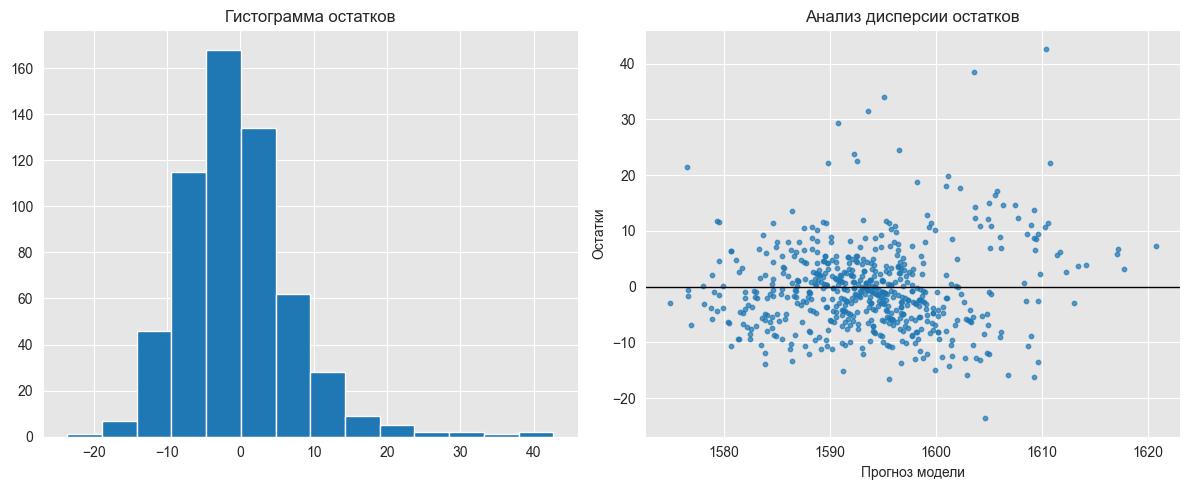

Среднее остатков: -0.45


In [38]:
bins = np.histogram_bin_edges(residuals, bins='doane')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(residuals, bins=bins)
axes[0].set_title('Гистограмма остатков')

axes[1].scatter(y_pred, residuals, s=10, alpha=0.7)
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('Прогноз модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии остатков')
plt.tight_layout()
plt.show()

print(f'Среднее остатков: {residuals.mean():.2f}')

In [39]:
print(f' Доля ошибок > 20 градусов: {(np.abs(residuals) > 20).mean():.1%}')

 Доля ошибок > 20 градусов: 2.1%


Среднее остатков около нуля это хороший показатель, на гистограмме виден хвост недооценённых значений вплоть до ошибки в 40 градусов таких партий около 2%, но всё же это не желательный результат учитывая то что мы хотим предотвращать высокую температуру.

На графике дисперсии не видно никаких закономерностей, но разброс остатков с увеличением прогноза шире за счёт выбросов.

Учитывая то что в наших данных были выбросы и признаки слабо объясняли целевой, результат можно назвать удовлетворительным.

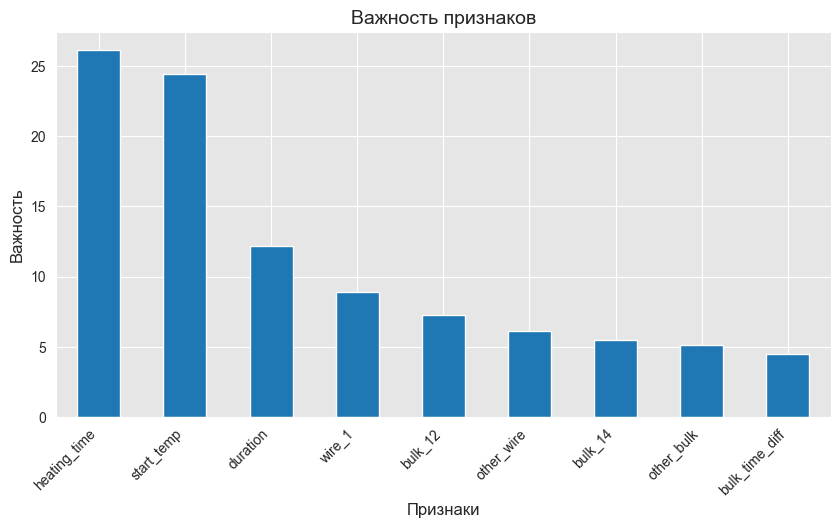

In [40]:
feature_importance = cat_model.get_feature_importance(type='FeatureImportance')
fi = pd.Series(feature_importance, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi.plot(kind='bar')
plt.title('Важность признаков', fontsize=14)
plt.ylabel('Важность', fontsize=12)
plt.xlabel('Признаки', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

Для модели бустинга наиболее важными также стали время нагрева, начальная температура и длительность между замерами температуры, далее идут материалы среди них самый полезный первый проволочный материал, время подачи сыпучих материалов влияет меньше всего, его можно убрать и качество модели станет незначительно хуже как было проверенно на обучающей выборке.

Чтобы лучше понимать как именно влияют признаки на прогноз построим график SHAP.

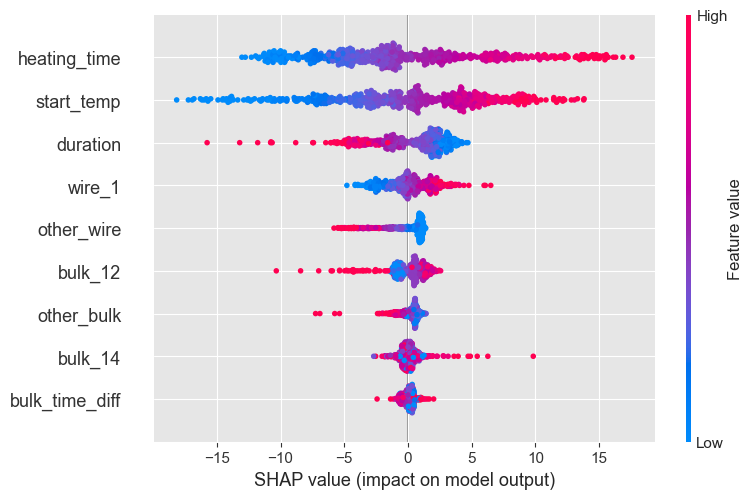

In [41]:
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot")

На графике по вертикали расположены признаки по важности, точки это объекты тестовой выборки. Цветом показана величина значения признака, положительный shap value означает влияние на увеличение прогноза и наоборот.

Большие значения времени нагрева и стартовой температуры увеличивают предсказательную температуру, модель уловила логику: чем дольше время нагрева и выше начальная температура металла тем горячее конечная температура партии.

Время между замерами наоборот при больших значениях даёт отрицательных вклад, тоже объяснимо чем дольше металл проходит обработку тем сильнее успевает остыть, это мы также подмечали при первом исследовании. 

Материалы имеют меньшее влияние на прогноз, первый проволочный материал при больших значениях склоняет прогноз в большую сторону, у редких проволочных материалов (все кроме первого) все низкие значения признака скопились в одну группу, большие значения дают вклад в понижение температуры.

Признаки сыпучих материалов наименее важны для прогноза, на графике видны смешные цвета: низкие и высокие значения признаков могут давать прогноз в положительную и отрицательную сторону, у 12, 14 и редких материалов ещё видно влияние высоких показателей, то время подачи имеет наименьший вклад, к тому же он максимально неопределённый, его действительно стоит исключить из признаков.

Разберём партии в которых модель ошиблась сильнее всего, чтобы лучше понимать как проходит прогноз.

In [42]:
errors = np.abs(y_test - y_pred)

error_df = pd.DataFrame({
    'true': y_test,
    'pred': y_pred,
    'abs_error': errors
}).reset_index(drop=True)

worst_idx = error_df.sort_values('abs_error', ascending=False).head(5).index.tolist()

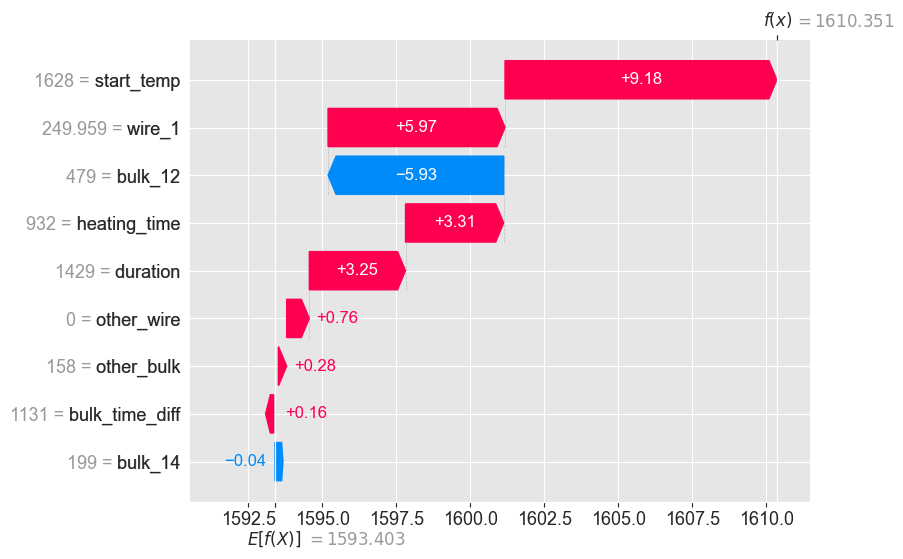

Истинная t: 1653.0, Прогноз t: 1610.4
Ошибка: 42.6


In [43]:
idx = worst_idx[0]

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=X_test.columns
)

shap.waterfall_plot(explanation)

print(f'Истинная t: {error_df.loc[idx, 'true']}, Прогноз t: {error_df.loc[idx, 'pred']:.1f}')
print(f'Ошибка: {error_df.loc[idx, 'abs_error']:.1f}')

In [44]:
y_train.max(), y_test.max()

(np.float64(1647.0), np.float64(1653.0))

В нашей тестовой выборке оказалась партия с самым высоким значением температруы во всех данных. Тк модели решающего дерева не умеют прогнозировать за пределами значений на которых обучались, ошибка получилась такой большой. 

Модель уловила все важные сигналы повышающие температуру: высокая начальная температура, долгий нагрев и большой объём wire_1, лишь bulk_12 дал вклад в уменьшение. У модели не было шанса сделать прогноз температуры таким высоким, хотя прогнозное значение не доходит и до предела тренировочной выборки (1647 градусов). 

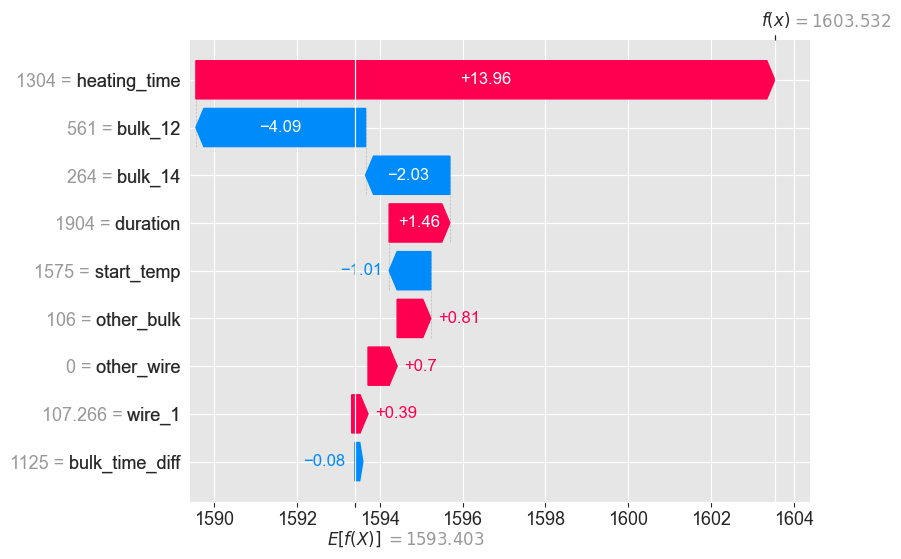

Истинная t: 1642.0, Прогноз t: 1603.5
Ошибка: 38.5


In [45]:
idx = worst_idx[1]

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=X_test.columns
)

shap.waterfall_plot(explanation)

print(f'Истинная t: {error_df.loc[idx, 'true']}, Прогноз t: {error_df.loc[idx, 'pred']:.1f}')
print(f'Ошибка: {error_df.loc[idx, 'abs_error']:.1f}')

Снова очень заниженная температура у одной из самых горячих партий, модель правильно оценила долгое время нагрева, но информация о сыпучих материалах слегка увела прогноз. Опять же даже если бы информация о bulk_12, 14 не повлияла, прогноз был бы выше всего на 6 градусов, это общая недооценка наиболее горячих партий, модель даже близко не угадала температуру.

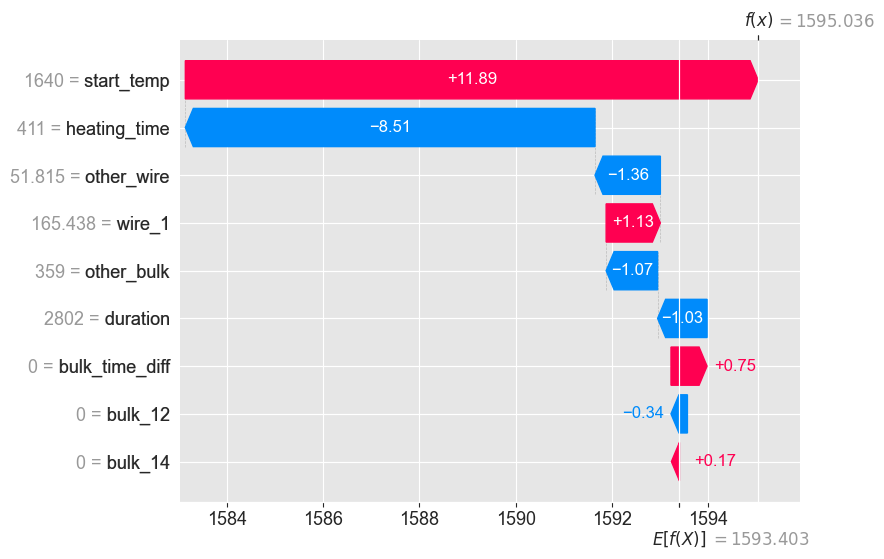

Истинная t: 1629.0, Прогноз t: 1595.0
Ошибка: 34.0


In [46]:
idx = worst_idx[2]

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=X_test.columns
)

shap.waterfall_plot(explanation)

print(f'Истинная t: {error_df.loc[idx, 'true']}, Прогноз t: {error_df.loc[idx, 'pred']:.1f}')
print(f'Ошибка: {error_df.loc[idx, 'abs_error']:.1f}')

2 самых важных признака дали противоречивый вклад, время нагрева действительно недолгое, а начальная температура действительно высокая, из-за чего прогноз получился немного выше среднего.

## Вывод

Целью работы было исследование данных о производстве металла и обучение модели для контроля температуры сплава. Данные из 7 разных источников содержали информацию о нагреве электродами, времени и количестве использованных проволочных и сыпучих материалов, объёме газа и изменениях температуры. После исследования и преобоработки данные были объеденены в итоговую таблицу. В данных содержалось большое количество пропусков.

Пропуски в данных о метариалах означали неиспользованию конкретного материала, редко используемые материалы были объединены в признаки `other_bulk` и `other_wire`. Часть партий - 23% не имела записей о всех замерах температуры кроме первого, такие партии были удаленны т.к в них остуствовал целевой признак. Были удалены 4 партии с аномально низкими значениями температуры, тк они ниже температуры плавления металла. Также встречались партии которые остуствовали в части источниках, они не были включены в итоговые данные для обучения. Отдельно было обнаруженно, что партии с пропусками в данных о материалах показывают наиболее высокие температуры среди всех партий. Возможным объяснением является отсуствие или сокращение цикла обработки который происходит после подачи материалов, но это лишь гипотеза.
<div align="center">
    <img src="nans_temp.png" width="70%">
</div>

Далее в исследовании итоговой таблицы мы обнаружили мультиколлинеарность между признаками одних процессов, а также слабую или умеренную связь с конечной температурой. Наиболее заметная связь с начальной температурой и первым проволочным материалом. Полиномиальные признаки усилили взаимосвязи, но при обучении лучших моделей они не потребовались, наоборот удаление наименее информативных признаков позволило улучшить качество.

В ходе экспериментов мы сравнили Линейную регрессию с регуляризацией, SVR и CatBoost. Простой прогноз средним показал MAE в 8 градусов, относительно этого результата качество удалось улучшить, лучшая линейная модель показала MAE 6.16, SVR 6.02 и CatBoost снизил ошибку до 5.88 граудсов на кросс-валидации. Наиболее лучшие результаты были получены на сокращенной выборке из 9 признаков. Для бустинга использование RMSE в качестве функции потерь оказалось эффективнее чем MAE, по этому эта связка была выбрана для тестирования. Подбор параметров выполнялся с помощью Optuna, параметры моделей и состав признаков фиксировались в MLflow.

На тестовой выборке модель показала `MAE = 5.67, RMSE = 7.68, R2 = 0.52`. Качество осталось на том же уровне что и при обучении на кросс-валдиации, что не указывает на переобучение. При этом в тестовую выборку попали партии с наиболее высокой температурой во всех данных, которые представляли для модели особую сложность из-за чего на данном этапе наблюдается недооценка самых высоких температур. Но даже с учётом этого ухудшения качества не наблюдалось. Анализ остатков не показал закономерностей или аномалий.

Исследование результатов теста с помощью SHAP показало, что наибольший вклад в прогноз вносили время нагрева электродами, стартовая температура и длительность обработки партии. Повышение начальной температуры и времени нагрева электродами в целом смещали прогноз в сторону высокой температуры и наоборот. Увеличение длительности обработки наоборот связанно со снижением прогноза, это согласуется с охлаждением металла после цикла операций. Влияние отдельных материалов оказалось наименее значимым, хотя большие объёмы первого проволочного материала были связаны с увеличением прогноза температуры. Время подачи сыпучих материалов оказалось наименее информативным признаком и его удаление не сильно ухудшало качество моделей.

Мы получили модель которая способна прогнозировать конечную температуру со средней абсолютной ошибкой около 5.7 градусов. Помимо этого мы определили наиболее значимые признаки процесса, выяснили что нет необходимости в большом кол-ве признаков. Рекомендуется боле подробное изучение системы записи процесса и исследование пропущенных в файлах с материалами партий, так как они показывали наибольшую температуру, возможно там больше информации о причинах повышенных температур.